# Category Top-4 Columns + EDA

카테고리별로 타깃(`avg_delay_minutes_next_30m`)과의 절대 상관이 높은 상위 4개 컬럼을 자동 선정하고,
선정 결과를 `df_col`로 저장한 뒤 EDA를 진행합니다.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

BASE_DIR = Path('..')
DATA_DIR = BASE_DIR / 'data'
CODE_DIR = BASE_DIR / 'code'

TRAIN_PATH = DATA_DIR / 'train.csv'
LAYOUT_PATH = DATA_DIR / 'layout_info.csv'
TARGET = 'avg_delay_minutes_next_30m'


In [2]:
train = pd.read_csv(TRAIN_PATH)
layout = pd.read_csv(LAYOUT_PATH)

# layout 정보 조인
df = train.merge(layout, on='layout_id', how='left')
print('df shape:', df.shape)
df.head()


df shape: (250000, 108)


,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,pack_station_count,charger_count,layout_compactness,zone_dispersion,robot_total,building_age_years,floor_area_sqm,ceiling_height_m,fire_sprinkler_count,emergency_exit_count
0,TRAIN_000000,WH_136,SC_07598,51.0,96.0,3.29,0.1176,0.1765,0.0392,0.3063,...,10.0,5.0,0.4276,0.2536,30,7,5961,6.0,56,4
1,TRAIN_000001,WH_136,SC_07598,NaN,93.0,2.55,0.0597,NaN,0.0149,NaN,...,10.0,5.0,0.4276,0.2536,30,7,5961,6.0,56,4
2,TRAIN_000002,WH_136,SC_07598,92.0,115.0,2.49,0.0652,0.2283,0.0217,0.3063,...,10.0,5.0,0.4276,0.2536,30,7,5961,6.0,56,4
3,TRAIN_000003,WH_136,SC_07598,77.0,110.0,2.52,0.0649,NaN,0.0390,0.3063,...,10.0,5.0,0.4276,0.2536,30,7,5961,6.0,56,4
4,TRAIN_000004,WH_136,SC_07598,NaN,122.0,3.12,0.0667,0.3333,NaN,0.3063,...,10.0,5.0,0.4276,0.2536,30,7,5961,6.0,56,4


In [3]:
# 카테고리 정의 (도메인 기준)
category_map = {
    '주문/수요': [
        'order_inflow_15m', 'unique_sku_15m', 'avg_items_per_order', 'urgent_order_ratio',
        'sku_concentration', 'order_wave_count', 'pick_list_length_avg', 'bulk_order_ratio',
        'return_order_ratio', 'prev_shift_volume'
    ],
    '로봇/배터리': [
        'robot_active', 'robot_idle', 'robot_charging', 'robot_utilization', 'avg_trip_distance',
        'task_reassign_15m', 'battery_mean', 'battery_std', 'low_battery_ratio',
        'charge_queue_length', 'avg_charge_wait', 'charge_efficiency_pct', 'battery_cycle_count_avg',
        'agv_task_success_rate', 'robot_calibration_score', 'avg_idle_duration_min',
        'robot_firmware_update_days'
    ],
    '혼잡/동선': [
        'congestion_score', 'max_zone_density', 'blocked_path_15m', 'near_collision_15m',
        'aisle_traffic_score', 'intersection_wait_time_avg', 'path_optimization_score',
        'storage_density_pct', 'vertical_utilization', 'racking_height_avg_m'
    ],
    '출고/패킹': [
        'replenishment_overlap', 'pack_utilization', 'loading_dock_util', 'conveyor_speed_mps',
        'outbound_truck_wait_min', 'dock_to_stock_hours', 'kpi_otd_pct', 'backorder_ratio',
        'sort_accuracy_pct', 'quality_check_rate', 'packaging_material_cost', 'label_print_queue',
        'pallet_wrap_time_min', 'cross_dock_ratio', 'express_lane_util', 'staging_area_util'
    ],
    '시스템/인프라': [
        'wms_response_time_ms', 'scanner_error_rate', 'wifi_signal_db', 'network_latency_ms',
        'air_quality_idx', 'co2_level_ppm', 'hvac_power_kw', 'ups_battery_pct',
        'ambient_noise_db', 'lighting_level_lux', 'lighting_zone_variance', 'floor_vibration_idx'
    ],
    '레이아웃/시설': [
        'aisle_width_avg', 'intersection_count', 'one_way_ratio', 'pack_station_count',
        'charger_count', 'layout_compactness', 'zone_dispersion', 'robot_total',
        'building_age_years', 'floor_area_sqm', 'ceiling_height_m',
        'fire_sprinkler_count', 'emergency_exit_count'
    ],
}

all_numeric = df.select_dtypes(include='number').columns.tolist()
corr_series = df[all_numeric].corr()[TARGET].drop(TARGET)


In [4]:
rows = []
for cat, cols in category_map.items():
    valid = [c for c in cols if c in corr_series.index]
    if not valid:
        continue

    s = corr_series[valid].dropna()
    s = s.reindex(s.abs().sort_values(ascending=False).index).head(4)

    for col, val in s.items():
        rows.append({
            'category': cat,
            'column': col,
            'corr': val,
            'abs_corr': abs(val),
            'missing_ratio': df[col].isna().mean(),
        })

df_col = pd.DataFrame(rows).sort_values(['category', 'abs_corr'], ascending=[True, False]).reset_index(drop=True)
df_col.to_csv(CODE_DIR / 'df_col.csv', index=False)

print('df_col rows:', len(df_col))
df_col


df_col rows: 24


,category,column,corr,abs_corr,missing_ratio
0,레이아웃/시설,pack_station_count,-0.186171,0.186171,0.000000
1,레이아웃/시설,robot_total,-0.110537,0.110537,0.000000
2,레이아웃/시설,emergency_exit_count,-0.044341,0.044341,0.000000
3,레이아웃/시설,zone_dispersion,-0.026672,0.026672,0.000000
4,로봇/배터리,low_battery_ratio,0.366073,0.366073,0.117616
5,로봇/배터리,battery_mean,-0.358886,0.358886,0.121280
6,로봇/배터리,robot_idle,-0.349311,0.349311,0.000000
7,로봇/배터리,robot_charging,0.320406,0.320406,0.000000
8,시스템/인프라,lighting_level_lux,0.012795,0.012795,0.118812
9,시스템/인프라,floor_vibration_idx,-0.010505,0.010505,0.118216


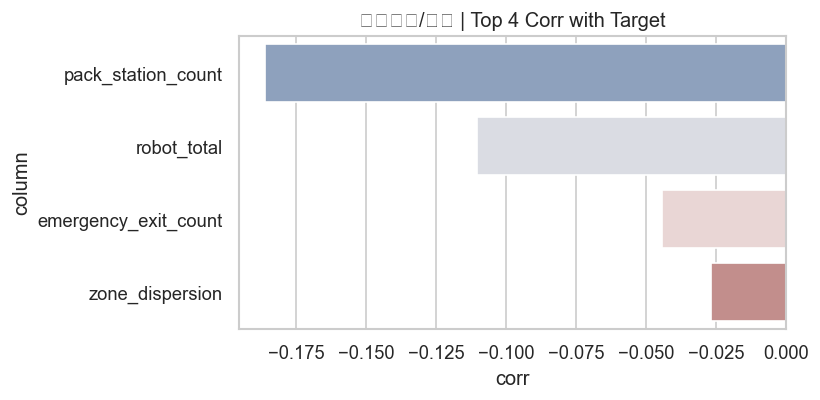

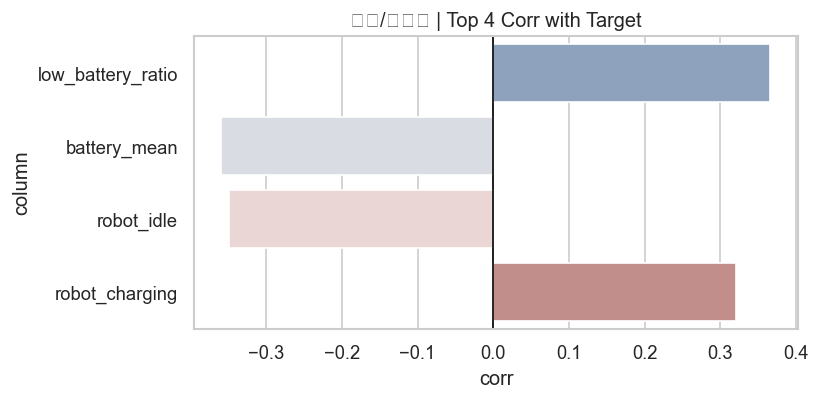

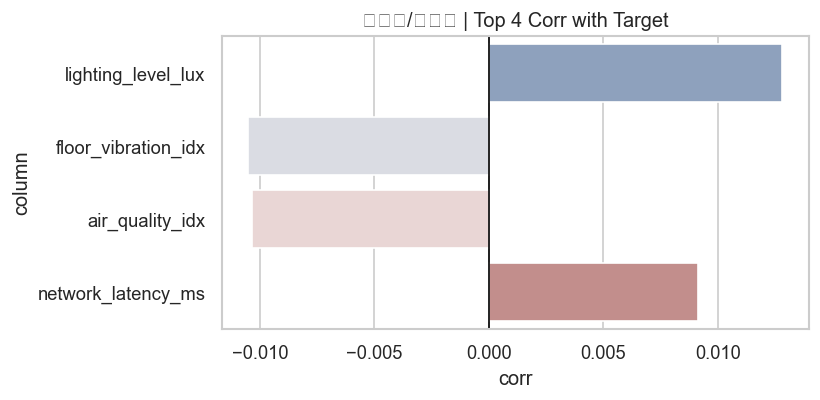

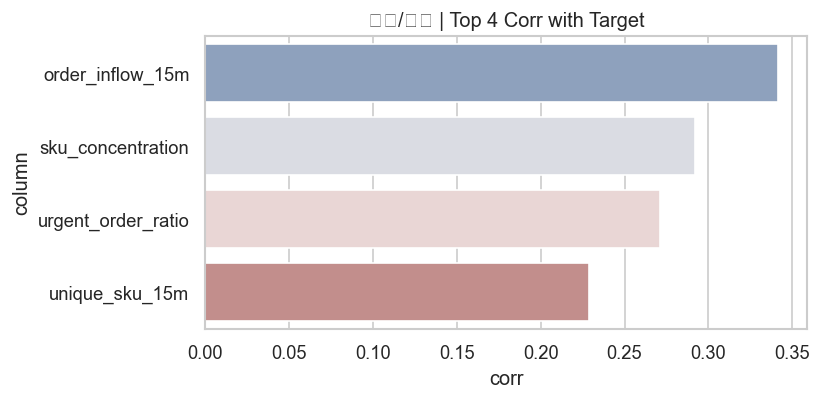

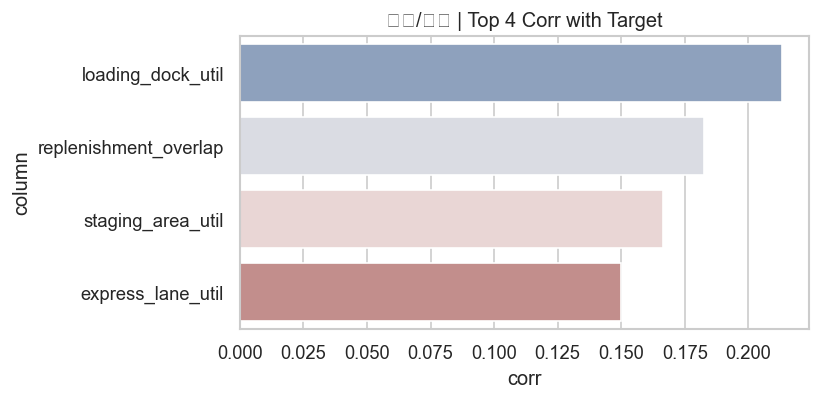

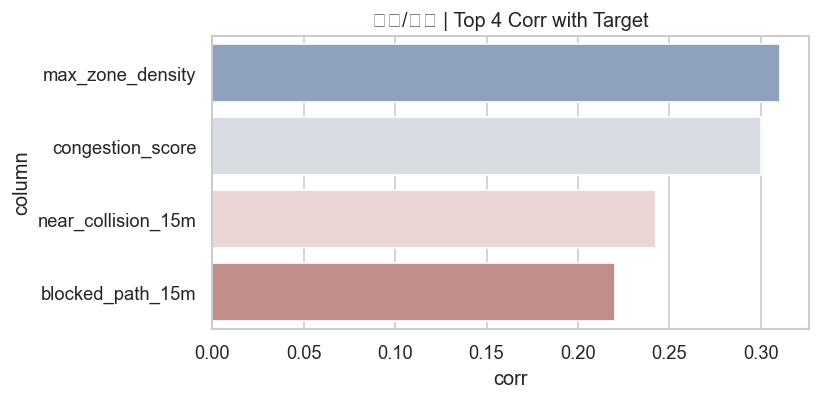

In [5]:
# 카테고리별 상위 4개 상관도 시각화
for cat in df_col['category'].unique():
    tmp = df_col[df_col['category'] == cat].copy()

    plt.figure(figsize=(7, 3.5))
    sns.barplot(data=tmp, x='corr', y='column', palette='vlag')
    plt.axvline(0, color='black', lw=1)
    plt.title(f'{cat} | Top 4 Corr with Target')
    plt.tight_layout()
    plt.show()


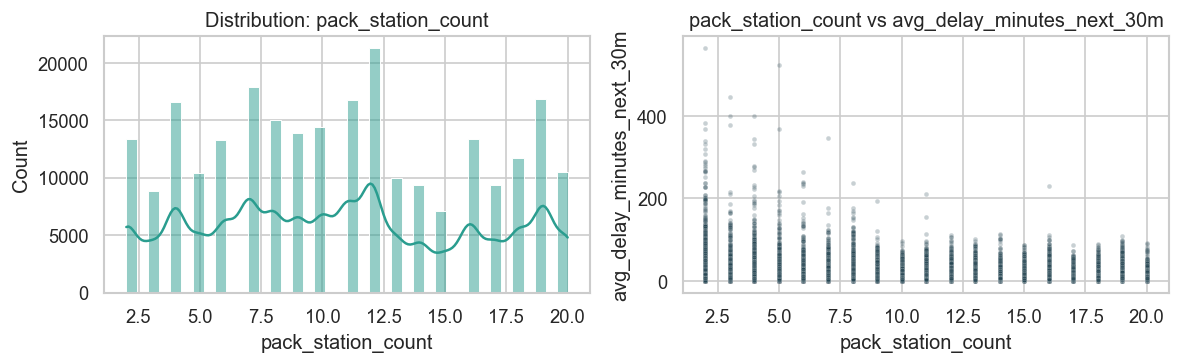

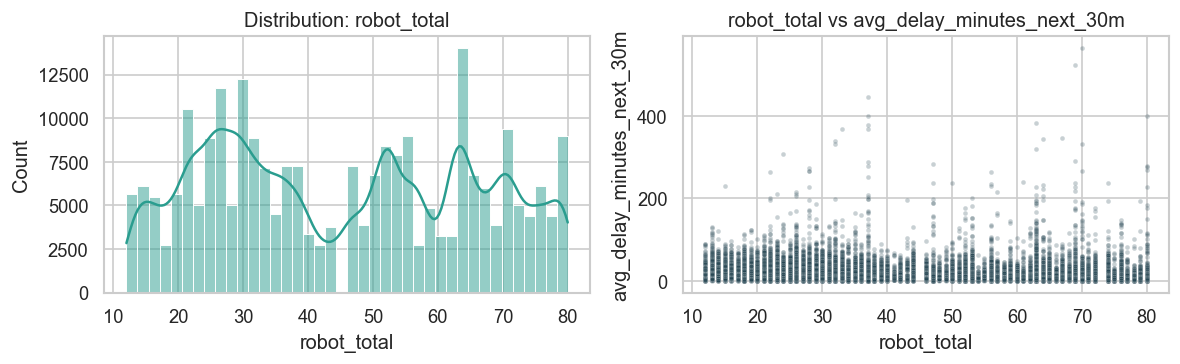

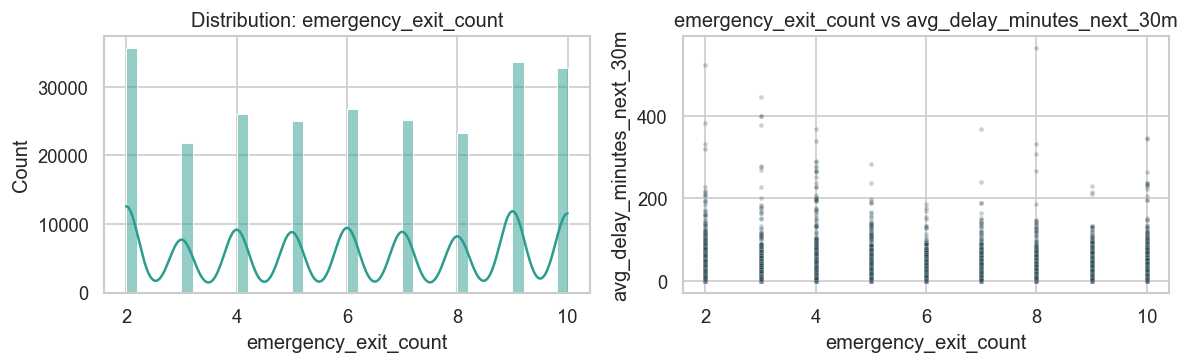

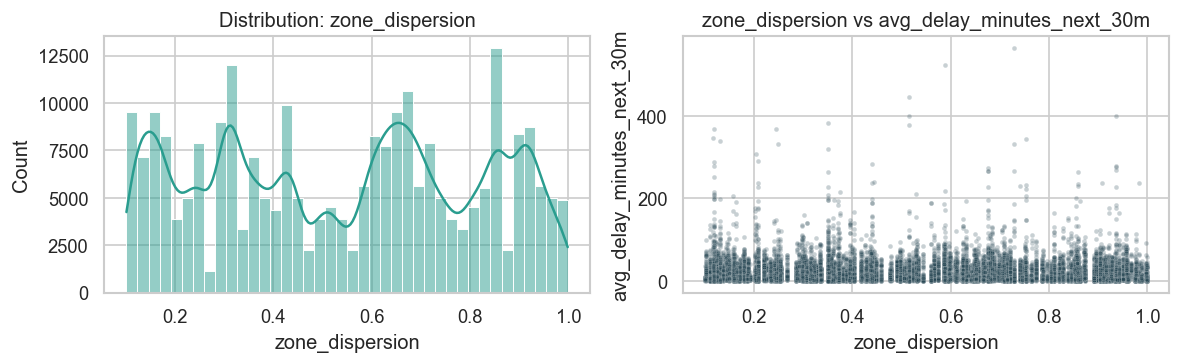

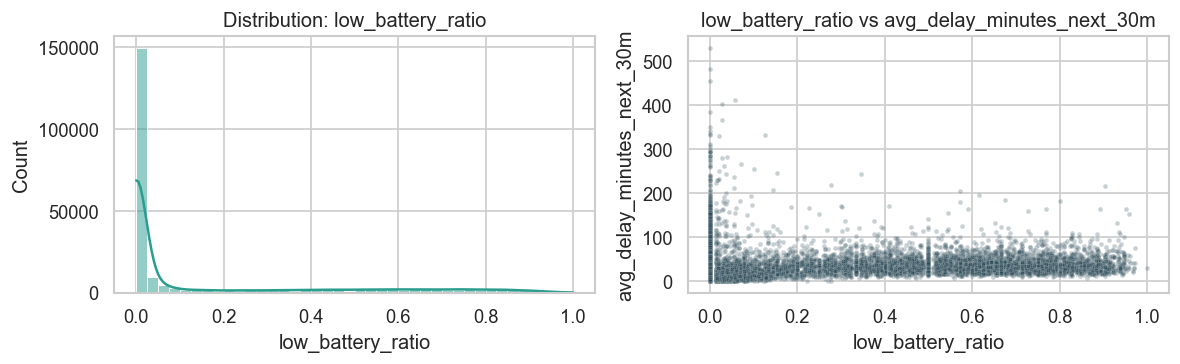

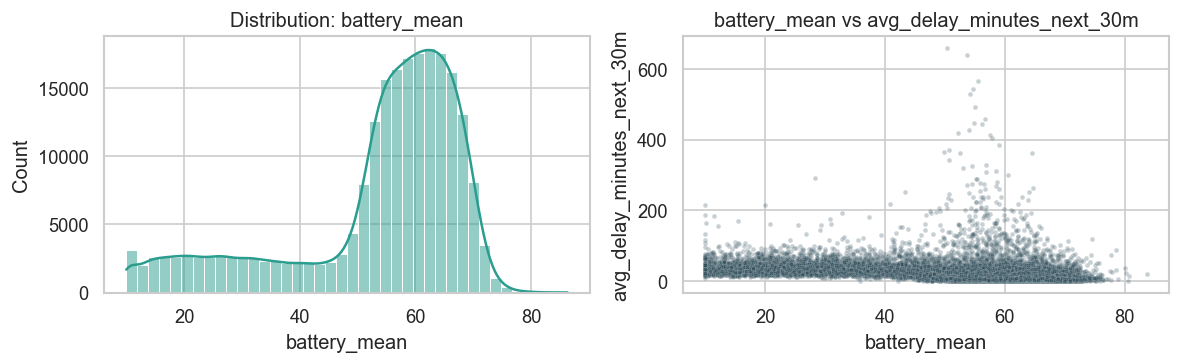

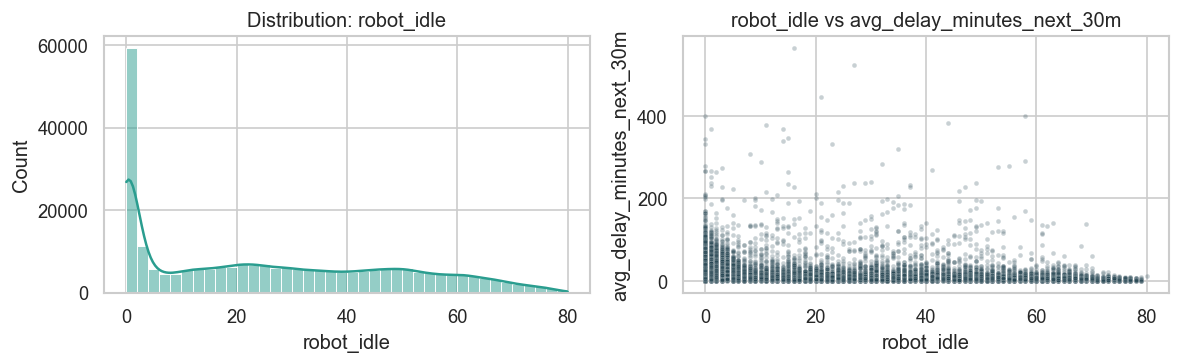

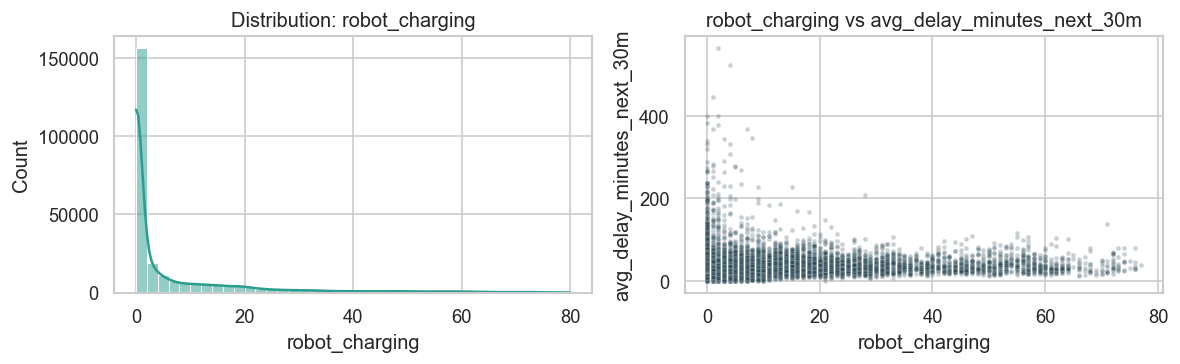

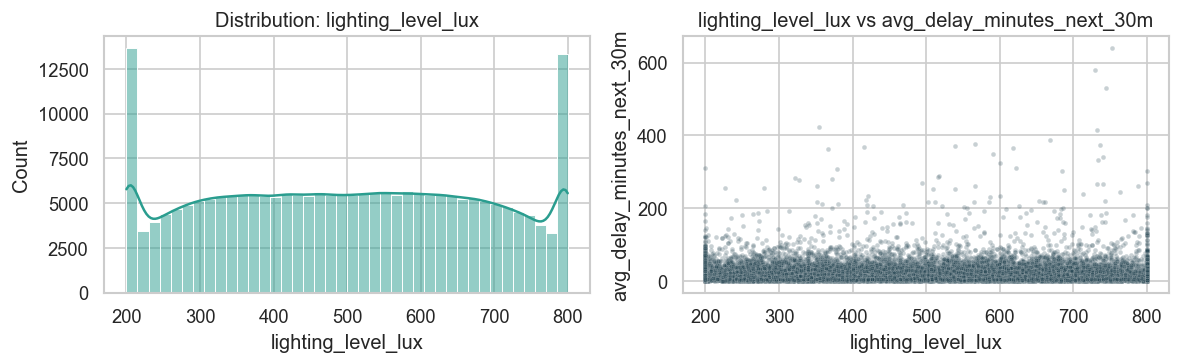

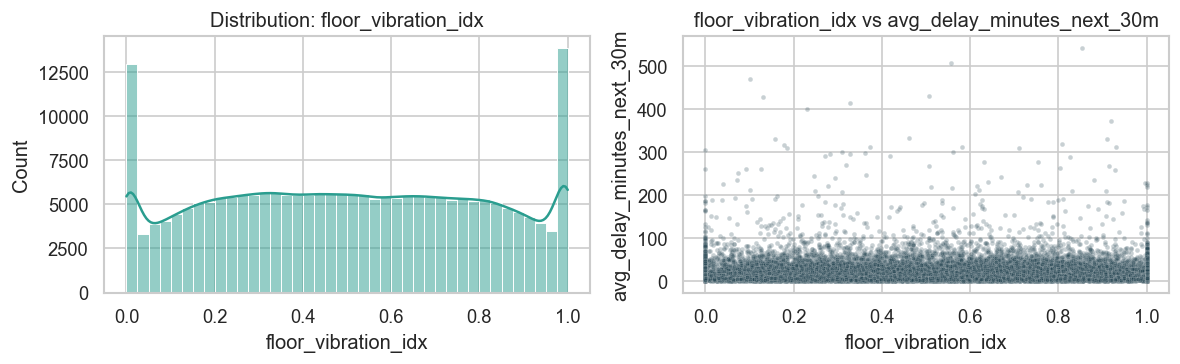

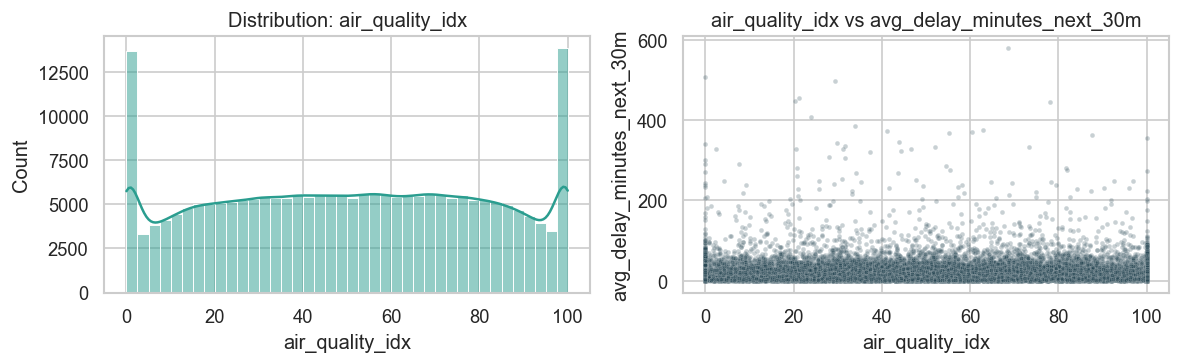

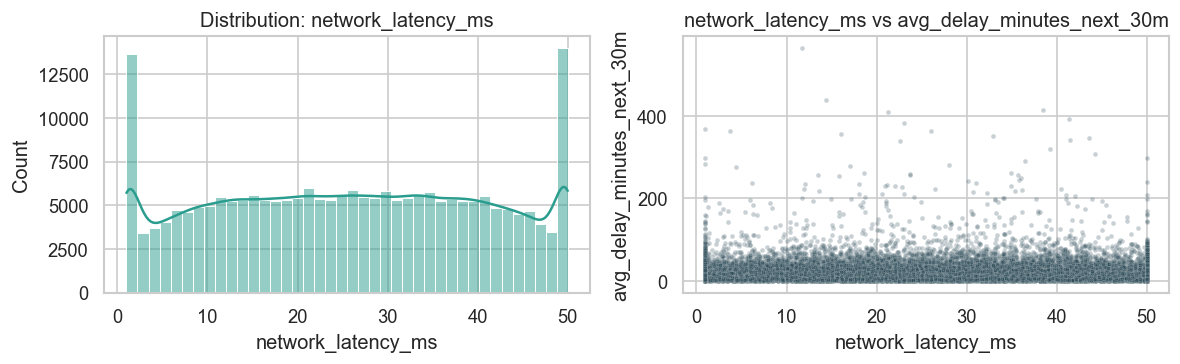

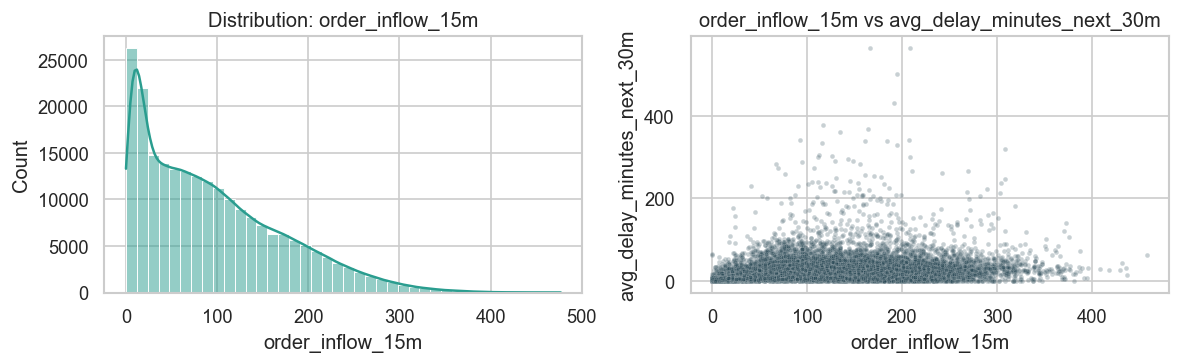

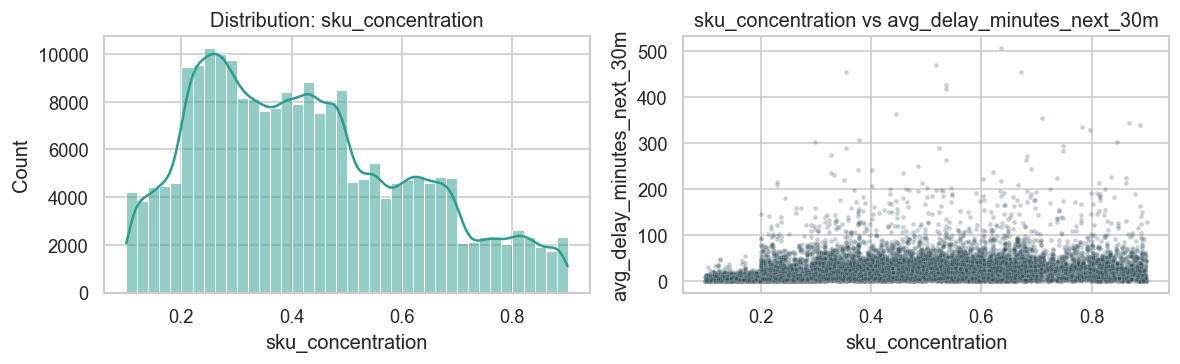

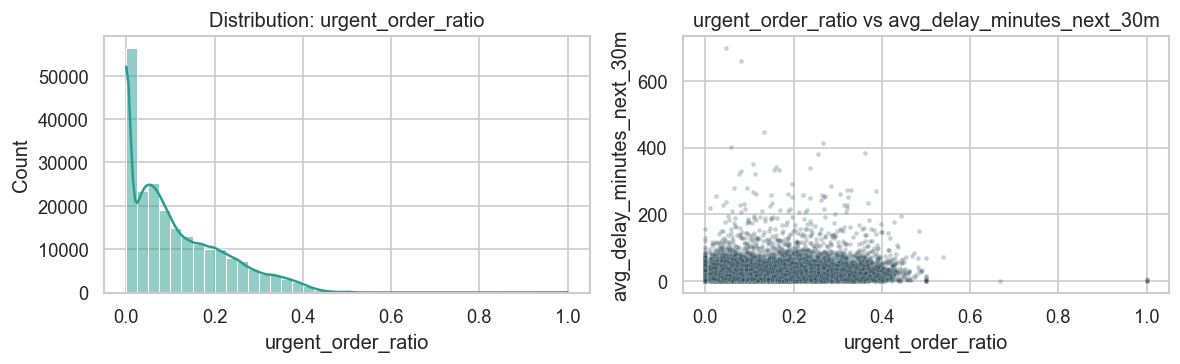

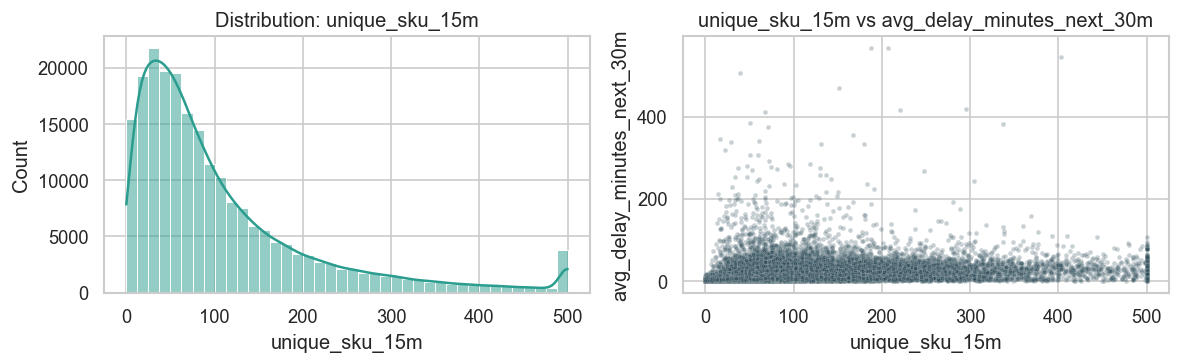

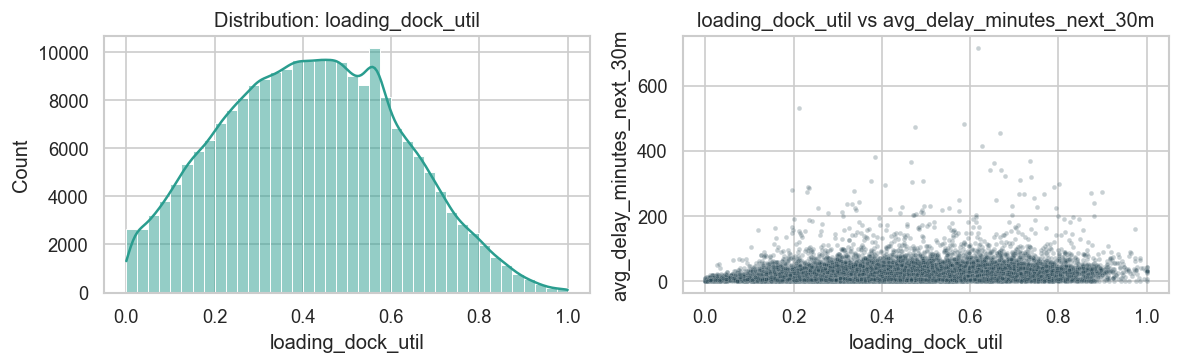

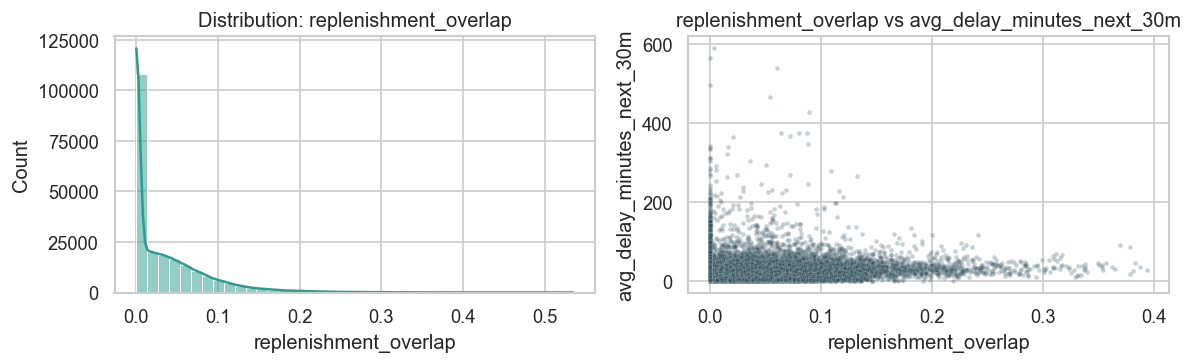

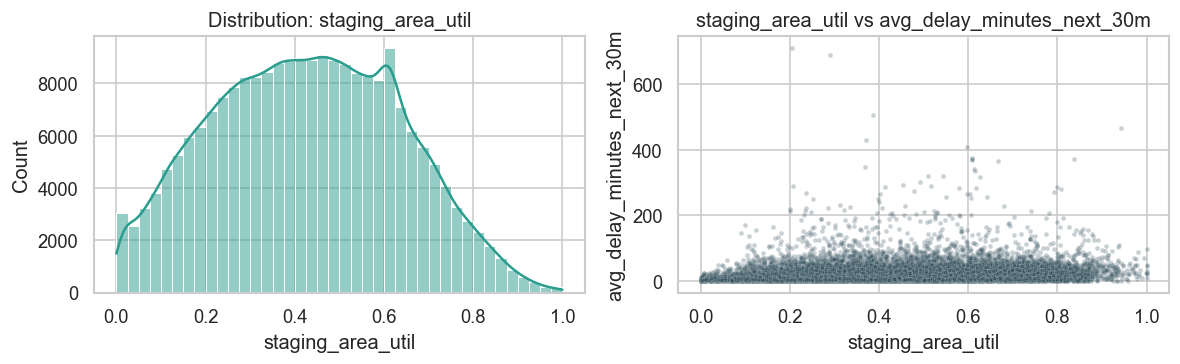

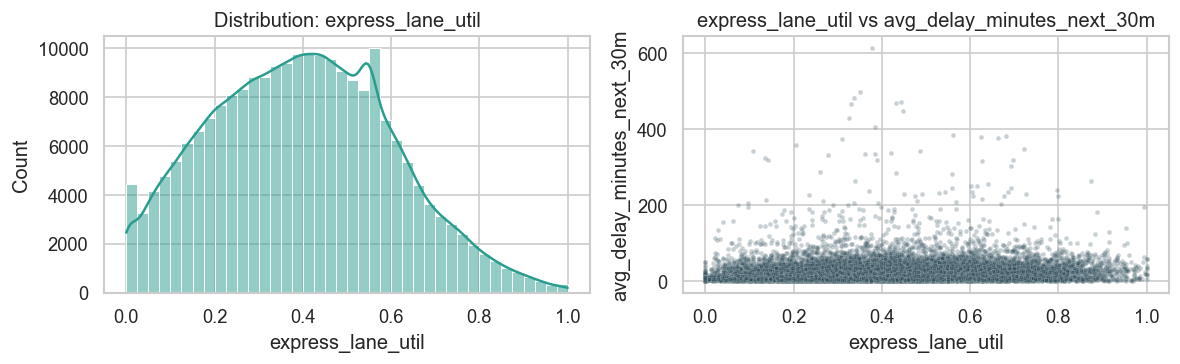

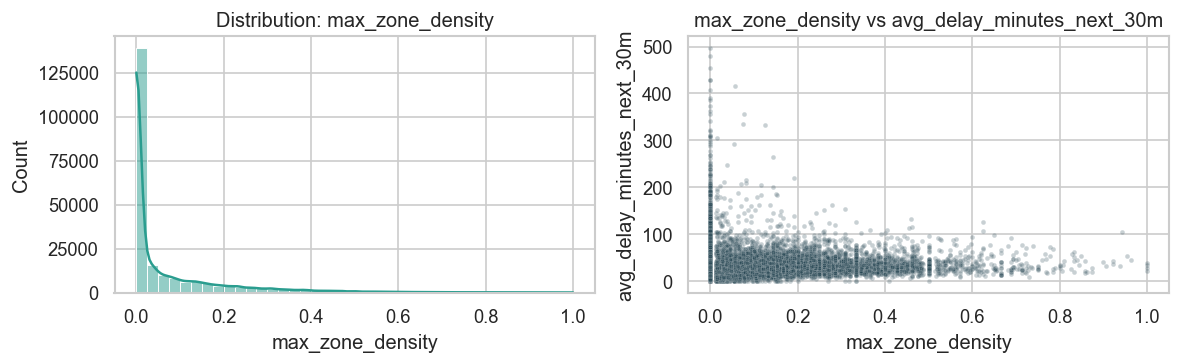

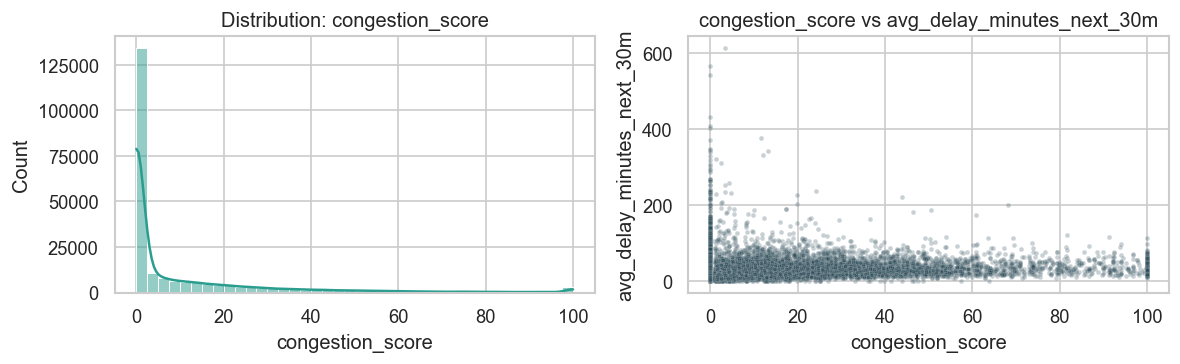

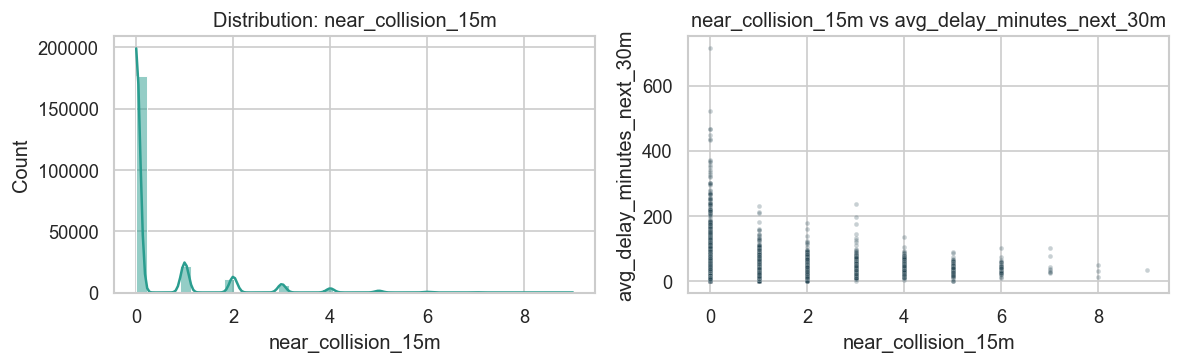

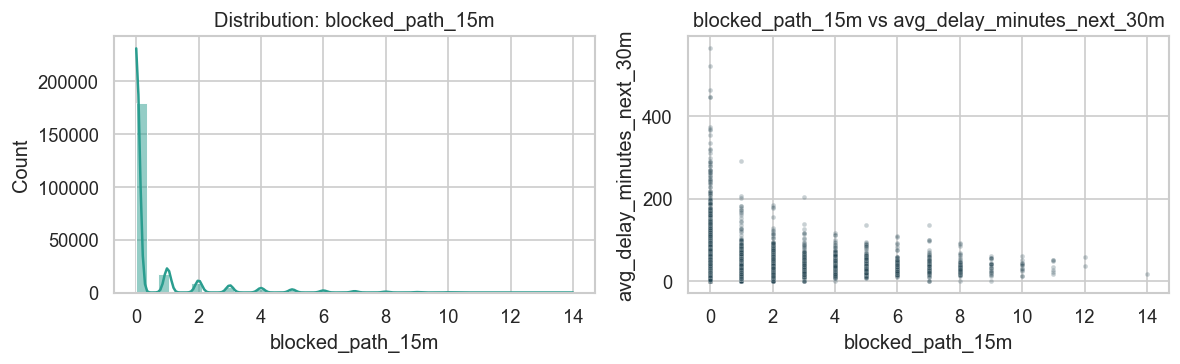

In [6]:
# 선정된 컬럼 EDA: 분포 + 타깃 산점도
selected_cols = df_col['column'].tolist()
eda_df = df[selected_cols + [TARGET]].copy()

for col in selected_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))

    sns.histplot(eda_df[col], bins=40, kde=True, ax=axes[0], color='#2a9d8f')
    axes[0].set_title(f'Distribution: {col}')

    sample = eda_df[[col, TARGET]].dropna()
    if len(sample) > 20000:
        sample = sample.sample(20000, random_state=42)
    sns.scatterplot(data=sample, x=col, y=TARGET, s=8, alpha=0.25, ax=axes[1], color='#264653')
    axes[1].set_title(f'{col} vs {TARGET}')

    plt.tight_layout()
    plt.show()


In [8]:
# 최종 요약 테이블
summary = []
for _, r in df_col.iterrows():
    c = r['column']
    summary.append({
        'category': r['category'],
        'column': c,
        'corr': r['corr'],
        'missing_ratio': r['missing_ratio'],
        'mean': df[c].mean(),
        'std': df[c].std(),
        'q25': df[c].quantile(0.25),
        'q50': df[c].quantile(0.50),
        'q75': df[c].quantile(0.75),
    })

summary_df = pd.DataFrame(summary).sort_values(['category', 'corr'], ascending=[True, False])
summary_df.to_csv(CODE_DIR / 'df_col_summary.csv', index=False)
summary_df


,category,column,corr,missing_ratio,mean,std,q25,q50,q75
3,레이아웃/시설,zone_dispersion,-0.026672,0.000000,0.540163,0.266866,0.3053,0.5733,0.7647
2,레이아웃/시설,emergency_exit_count,-0.044341,0.000000,6.073500,2.712402,4.0000,6.0000,9.0000
1,레이아웃/시설,robot_total,-0.110537,0.000000,45.321500,19.834483,28.0000,46.0000,63.0000
0,레이아웃/시설,pack_station_count,-0.186171,0.000000,10.751500,5.323144,6.7500,11.0000,15.0000
4,로봇/배터리,low_battery_ratio,0.366073,0.117616,0.136184,0.256153,0.0000,0.0000,0.0909
7,로봇/배터리,robot_charging,0.320406,0.000000,6.128704,12.433735,0.0000,0.0000,6.0000
6,로봇/배터리,robot_idle,-0.349311,0.000000,25.813408,22.687023,2.0000,23.0000,45.0000
5,로봇/배터리,battery_mean,-0.358886,0.121280,53.454728,15.378697,50.3800,58.0700,64.0000
8,시스템/인프라,lighting_level_lux,0.012795,0.118812,498.177751,179.757618,347.0000,498.0000,648.0000
11,시스템/인프라,network_latency_ms,0.009115,0.118816,25.653141,14.711809,13.3000,25.7000,38.0000


## Modeling with `df_col` Features

`df_col.csv`에서 선택된 컬럼만 사용해서 GroupKFold + LightGBM 모델을 학습하고 제출 파일을 생성합니다.

In [9]:
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error

TARGET = 'avg_delay_minutes_next_30m'

train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
layout = pd.read_csv(DATA_DIR / 'layout_info.csv')
df_col = pd.read_csv(CODE_DIR / 'df_col.csv')

train = train.merge(layout, on='layout_id', how='left')
test = test.merge(layout, on='layout_id', how='left')

selected_cols = df_col['column'].drop_duplicates().tolist()
print('selected features:', len(selected_cols))
print(selected_cols)


selected features: 24
['pack_station_count', 'robot_total', 'emergency_exit_count', 'zone_dispersion', 'low_battery_ratio', 'battery_mean', 'robot_idle', 'robot_charging', 'lighting_level_lux', 'floor_vibration_idx', 'air_quality_idx', 'network_latency_ms', 'order_inflow_15m', 'sku_concentration', 'urgent_order_ratio', 'unique_sku_15m', 'loading_dock_util', 'replenishment_overlap', 'staging_area_util', 'express_lane_util', 'max_zone_density', 'congestion_score', 'near_collision_15m', 'blocked_path_15m']


In [10]:
X_train = train[selected_cols].copy()
X_test = test[selected_cols].copy()
y = train[TARGET].copy()
groups = train['scenario_id'].copy()
test_id = test['ID'].copy()

# 결측 처리: 중앙값 + 결측 indicator
for c in selected_cols:
    if X_train[c].isna().any():
        X_train[f'is_null_{c}'] = X_train[c].isna().astype(np.int8)
        X_test[f'is_null_{c}'] = X_test[c].isna().astype(np.int8)

med = X_train.median(numeric_only=True)
X_train = X_train.fillna(med)
X_test = X_test.fillna(med)

# 이상치 완화 클리핑
lower = X_train.quantile(0.005)
upper = X_train.quantile(0.995)
X_train = X_train.clip(lower=lower, upper=upper, axis=1)
X_test = X_test.clip(lower=lower, upper=upper, axis=1)

print('train shape:', X_train.shape, 'test shape:', X_test.shape)


train shape: (250000, 42) test shape: (50000, 42)


In [11]:
gkf = GroupKFold(n_splits=5)
oof = np.zeros(len(X_train))
pred_test = np.zeros(len(X_test))

params = dict(
    objective='mae',
    metric='l1',
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=60,
    subsample=0.85,
    subsample_freq=1,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_train, y, groups), 1):
    print(f'--- Fold {fold} ---')
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    model = LGBMRegressor(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric='l1',
        callbacks=[early_stopping(100), log_evaluation(200)]
    )

    oof[va_idx] = model.predict(X_va, num_iteration=model.best_iteration_)
    pred_test += model.predict(X_test, num_iteration=model.best_iteration_) / 5

cv_mae = mean_absolute_error(y, oof)
print(f'OOF MAE: {cv_mae:.5f}')


--- Fold 1 ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015557 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4612
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 42
[LightGBM] [Info] Start training from score 9.098197
Training until validation scores don't improve for 100 rounds
[200]	valid_0's l1: 9.212
[400]	valid_0's l1: 9.18442
Early stopping, best iteration is:
[434]	valid_0's l1: 9.18329
--- Fold 2 ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011590 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4611
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 42
[LightGBM] [Info] Start traini

In [12]:
sub = pd.DataFrame({
    'ID': test_id,
    TARGET: pred_test
}).sort_values('ID').reset_index(drop=True)

out_path = CODE_DIR / 'submission_df_col.csv'
sub.to_csv(out_path, index=False)
print('saved:', out_path)
sub.head()


saved: ../code/submission_df_col.csv


,ID,avg_delay_minutes_next_30m
0,TEST_000000,16.382277
1,TEST_000001,15.665674
2,TEST_000002,19.158952
3,TEST_000003,18.225992
4,TEST_000004,16.880271


### ===============================

## 사용자 지정 10개 주제 피처만으로 `df` 생성

아래 셀은 요청한 주제(배터리충전, 혼잡충돌, 주문수요, 로봇AGV, KPI성과, 인력안전, 물류재고, 환경시설, 외부날씨, 인프라)와 관련된 컬럼만 선택해 `df`를 만듭니다.

In [13]:
# train + layout_info 기준으로 요청한 주제 컬럼만 구성
train = pd.read_csv(DATA_DIR / 'train.csv')
layout = pd.read_csv(DATA_DIR / 'layout_info.csv')
base = train.merge(layout, on='layout_id', how='left')

feature_groups = {
    '배터리_충전': [
        'battery_mean', 'battery_std', 'low_battery_ratio', 'charge_queue_length',
        'avg_charge_wait', 'charge_efficiency_pct', 'battery_cycle_count_avg', 'ups_battery_pct'
    ],
    '혼잡_충돌': [
        'congestion_score', 'max_zone_density', 'blocked_path_15m', 'near_collision_15m',
        'aisle_traffic_score', 'intersection_wait_time_avg', 'path_optimization_score'
    ],
    '주문_수요': [
        'order_inflow_15m', 'unique_sku_15m', 'avg_items_per_order', 'urgent_order_ratio',
        'sku_concentration', 'order_wave_count', 'pick_list_length_avg', 'bulk_order_ratio',
        'prev_shift_volume', 'return_order_ratio'
    ],
    '로봇_AGV': [
        'robot_active', 'robot_idle', 'robot_charging', 'robot_utilization',
        'avg_trip_distance', 'task_reassign_15m', 'agv_task_success_rate',
        'robot_calibration_score', 'robot_firmware_update_days', 'avg_idle_duration_min'
    ],
    'KPI_성과': [
        'kpi_otd_pct', 'sort_accuracy_pct', 'quality_check_rate', 'daily_forecast_accuracy',
        'barcode_read_success_rate', 'manual_override_ratio'
    ],
    '인력_안전': [
        'worker_avg_tenure_months', 'safety_score_monthly', 'staff_on_floor',
        'forklift_active_count', 'label_print_queue', 'shift_handover_delay_min'
    ],
    '물류_재고': [
        'inventory_turnover_rate', 'replenishment_overlap', 'staging_area_util',
        'pack_utilization', 'loading_dock_util', 'conveyor_speed_mps',
        'dock_to_stock_hours', 'outbound_truck_wait_min', 'cross_dock_ratio',
        'storage_density_pct', 'vertical_utilization', 'racking_height_avg_m',
        'avg_package_weight_kg', 'packaging_material_cost', 'pallet_wrap_time_min'
    ],
    '환경_시설': [
        'warehouse_temp_avg', 'humidity_pct', 'cold_storage_temp_c', 'zone_temp_variance',
        'lighting_level_lux', 'lighting_zone_variance', 'ambient_noise_db',
        'floor_vibration_idx', 'air_quality_idx', 'co2_level_ppm', 'hvac_power_kw',
        'aisle_width_avg', 'intersection_count', 'one_way_ratio', 'pack_station_count',
        'charger_count', 'layout_compactness', 'zone_dispersion', 'robot_total',
        'building_age_years', 'floor_area_sqm', 'ceiling_height_m',
        'fire_sprinkler_count', 'emergency_exit_count', 'maintenance_schedule_score',
        'fleet_age_months_avg'
    ],
    '외부_날씨': [
        'day_of_week', 'external_temp_c', 'wind_speed_kmh', 'precipitation_mm'
    ],
    '인프라': [
        'wms_response_time_ms', 'scanner_error_rate', 'wifi_signal_db', 'network_latency_ms'
    ],
}

id_cols = ['ID', 'layout_id', 'scenario_id', 'avg_delay_minutes_next_30m']

selected_cols = []
rows = []
for group_name, cols in feature_groups.items():
    valid = [c for c in cols if c in base.columns]
    selected_cols.extend(valid)
    rows.extend([{'group': group_name, 'column': c} for c in valid])

selected_cols = list(dict.fromkeys(selected_cols))
df_col_group = pd.DataFrame(rows)
df_col_group.to_csv(CODE_DIR / 'df_col_grouped.csv', index=False)

df = base[id_cols + selected_cols].copy()
print('최종 df shape:', df.shape)
print('선택 피처 수:', len(selected_cols))
print(df_col_group.groupby('group').size())
df.head()


최종 df shape: (250000, 100)
선택 피처 수: 96
group
KPI_성과     6
로봇_AGV    10
물류_재고     15
배터리_충전     8
외부_날씨      4
인력_안전      6
인프라        4
주문_수요     10
혼잡_충돌      7
환경_시설     26
dtype: int64


,ID,layout_id,scenario_id,avg_delay_minutes_next_30m,battery_mean,battery_std,low_battery_ratio,charge_queue_length,avg_charge_wait,charge_efficiency_pct,...,maintenance_schedule_score,fleet_age_months_avg,day_of_week,external_temp_c,wind_speed_kmh,precipitation_mm,wms_response_time_ms,scanner_error_rate,wifi_signal_db,network_latency_ms
0,TRAIN_000000,WH_136,SC_07598,5.554758,70.58,NaN,0.0,0.0,0.0,93.0,...,70.0,15.5,2.0,-2.8,NaN,26.7,212.0,0.0139,NaN,40.2
1,TRAIN_000001,WH_136,SC_07598,5.039834,69.87,17.6,0.0,0.0,NaN,90.8,...,70.1,21.0,1.0,NaN,29.1,19.7,229.0,0.0066,-46.9,39.9
2,TRAIN_000002,WH_136,SC_07598,5.920881,69.15,17.6,NaN,0.0,0.0,88.1,...,70.4,16.0,2.0,1.2,34.1,26.7,338.0,NaN,-47.1,38.2
3,TRAIN_000003,WH_136,SC_07598,5.540926,68.43,17.6,0.0,0.0,0.0,91.6,...,70.2,24.4,3.0,-0.5,33.5,23.7,291.0,0.0192,NaN,33.2
4,TRAIN_000004,WH_136,SC_07598,3.940071,67.71,17.6,0.0,0.0,0.0,90.4,...,71.6,22.9,1.0,-5.0,NaN,21.1,228.0,0.0106,-57.3,NaN


## 그룹별 상관 상위 2개 컬럼 선택

`df_col_grouped.csv` 기준으로 각 그룹에서 타깃과 절대 상관계수가 가장 높은 2개 컬럼만 선택합니다.

In [14]:
# df: 앞 셀에서 만들어진 사용자 지정 피처 DataFrame
TARGET = 'avg_delay_minutes_next_30m'
group_map = pd.read_csv(CODE_DIR / 'df_col_grouped.csv')

# 수치형 상관계수 계산
num_cols = [c for c in df.columns if c != TARGET and pd.api.types.is_numeric_dtype(df[c])]
corr_to_target = df[num_cols + [TARGET]].corr()[TARGET].drop(TARGET)

rows = []
for g, gdf in group_map.groupby('group'):
    candidates = [c for c in gdf['column'].tolist() if c in corr_to_target.index]
    if not candidates:
        continue

    s = corr_to_target[candidates].dropna()
    top2 = s.reindex(s.abs().sort_values(ascending=False).index).head(2)

    for col, val in top2.items():
        rows.append({
            'group': g,
            'column': col,
            'corr_with_target': val,
            'abs_corr_with_target': abs(val),
            'missing_ratio': df[col].isna().mean()
        })

df_top2 = pd.DataFrame(rows).sort_values(['group', 'abs_corr_with_target'], ascending=[True, False]).reset_index(drop=True)
df_top2.to_csv(CODE_DIR / 'df_top2_per_group.csv', index=False)

print('선택된 컬럼 수:', len(df_top2), '(그룹 x 2)')
display(df_top2)


선택된 컬럼 수: 20 (그룹 x 2)


,group,column,corr_with_target,abs_corr_with_target,missing_ratio
0,KPI_성과,manual_override_ratio,0.196444,0.196444,0.118136
1,KPI_성과,daily_forecast_accuracy,-0.118512,0.118512,0.118284
2,로봇_AGV,robot_idle,-0.349311,0.349311,0.000000
3,로봇_AGV,robot_charging,0.320406,0.320406,0.000000
4,물류_재고,loading_dock_util,0.213132,0.213132,0.118000
5,물류_재고,replenishment_overlap,0.182754,0.182754,0.118084
6,배터리_충전,low_battery_ratio,0.366073,0.366073,0.117616
7,배터리_충전,battery_mean,-0.358886,0.358886,0.121280
8,외부_날씨,external_temp_c,-0.012714,0.012714,0.118808
9,외부_날씨,precipitation_mm,-0.004036,0.004036,0.118580


## 선택 컬럼별 상관 높은 컬럼 보기

선택된 각 컬럼마다, 동일한 `df` 안에서 상관관계(절대값)가 높은 상위 컬럼을 보여줍니다.

In [15]:
selected_cols = df_top2['column'].tolist()
corr_mat = df[num_cols + [TARGET]].corr()

peer_rows = []
for col in selected_cols:
    if col not in corr_mat.columns:
        continue

    s = corr_mat[col].drop(labels=[col], errors='ignore').dropna()
    # 타깃 외 피처 중 상위 5개
    s_feat = s.drop(labels=[TARGET], errors='ignore')
    top_peers = s_feat.reindex(s_feat.abs().sort_values(ascending=False).index).head(5)

    for peer_col, peer_corr in top_peers.items():
        peer_rows.append({
            'feature': col,
            'peer_feature': peer_col,
            'corr': peer_corr,
            'abs_corr': abs(peer_corr)
        })

peer_df = pd.DataFrame(peer_rows).sort_values(['feature', 'abs_corr'], ascending=[True, False]).reset_index(drop=True)
peer_df.to_csv(CODE_DIR / 'df_top2_peer_corr.csv', index=False)
display(peer_df)


,feature,peer_feature,corr,abs_corr
0,battery_mean,low_battery_ratio,-0.933971,0.933971
1,battery_mean,robot_charging,-0.802619,0.802619
2,battery_mean,charge_queue_length,-0.720402,0.720402
3,battery_mean,avg_charge_wait,-0.714075,0.714075
4,battery_mean,robot_idle,0.538179,0.538179
...,...,...,...,...
95,wms_response_time_ms,hvac_power_kw,0.022259,0.022259
96,wms_response_time_ms,kpi_otd_pct,-0.021916,0.021916
97,wms_response_time_ms,daily_forecast_accuracy,-0.020800,0.020800
98,wms_response_time_ms,pack_utilization,0.019012,0.019012


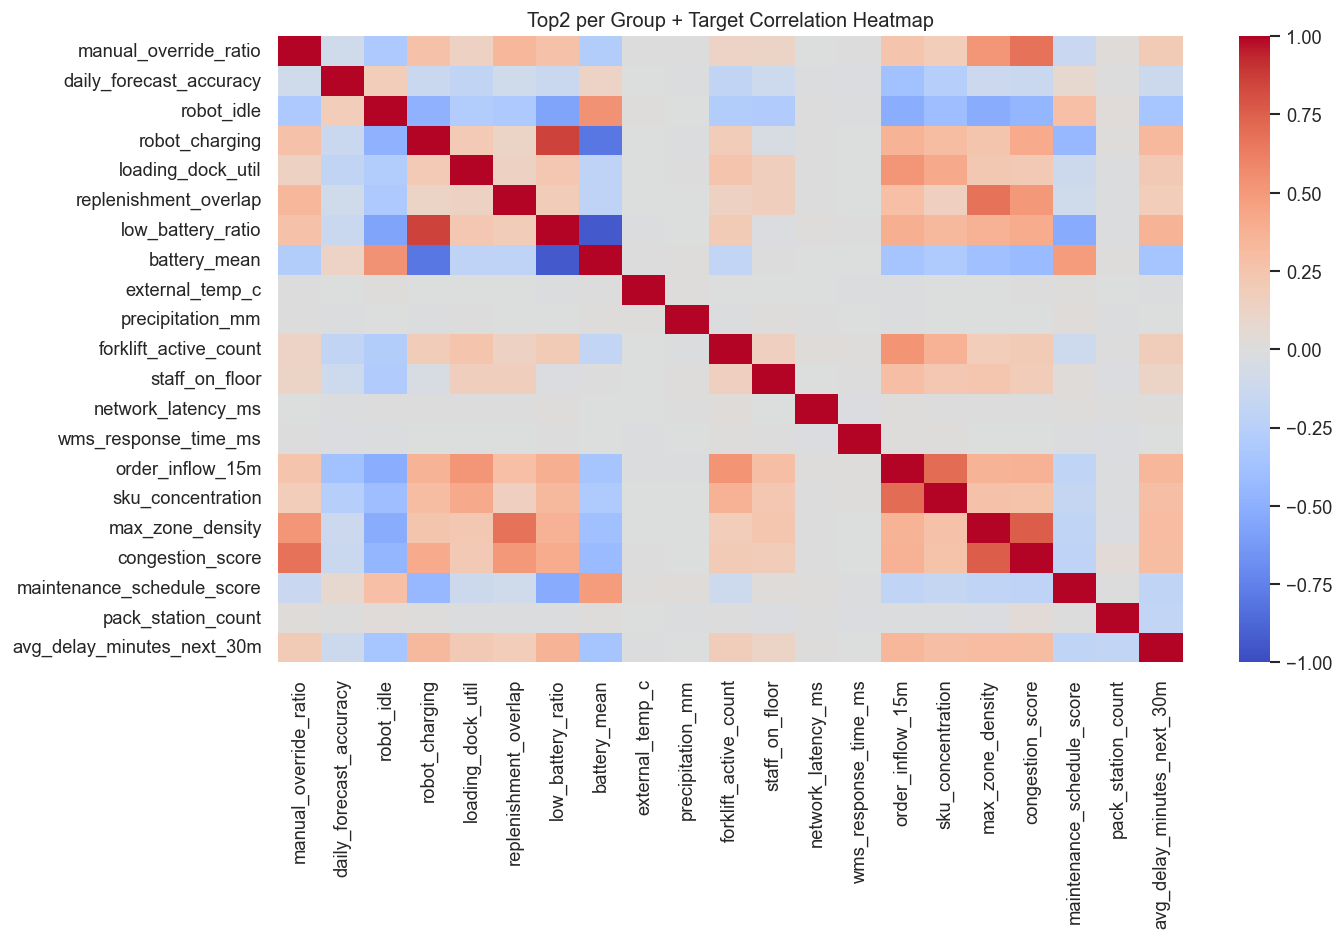

In [16]:
# 시각화: 선택된 top2 컬럼 + 타깃의 상관 히트맵
plot_cols = selected_cols + [TARGET]
plot_corr = df[plot_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(plot_corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Top2 per Group + Target Correlation Heatmap')
plt.tight_layout()
plt.show()


In [17]:
# 모델용 최소 피처셋 생성 (ID/그룹키/타깃 + 그룹별 top2)
model_cols = ['ID', 'layout_id', 'scenario_id', TARGET] + selected_cols
model_cols = list(dict.fromkeys(model_cols))
df_model_top2 = df[model_cols].copy()
df_model_top2.to_csv(CODE_DIR / 'df_model_top2.csv', index=False)

print('df_model_top2 shape:', df_model_top2.shape)
df_model_top2.head()


df_model_top2 shape: (250000, 24)


,ID,layout_id,scenario_id,avg_delay_minutes_next_30m,manual_override_ratio,daily_forecast_accuracy,robot_idle,robot_charging,loading_dock_util,replenishment_overlap,...,forklift_active_count,staff_on_floor,network_latency_ms,wms_response_time_ms,order_inflow_15m,sku_concentration,max_zone_density,congestion_score,maintenance_schedule_score,pack_station_count
0,TRAIN_000000,WH_136,SC_07598,5.554758,0.0144,0.7206,21,0,0.6268,0.0867,...,2.0,18.0,40.2,212.0,51.0,0.3063,0.0,0.0,70.0,10.0
1,TRAIN_000001,WH_136,SC_07598,5.039834,0.0144,0.6392,18,0,NaN,NaN,...,4.0,NaN,39.9,229.0,NaN,NaN,0.0,0.0,70.1,10.0
2,TRAIN_000002,WH_136,SC_07598,5.920881,0.0144,0.7145,14,0,0.6566,0.0014,...,3.0,21.0,38.2,338.0,92.0,0.3063,0.0,0.0,70.4,10.0
3,TRAIN_000003,WH_136,SC_07598,5.540926,0.0144,0.6516,17,0,0.6594,0.0406,...,NaN,28.0,33.2,291.0,77.0,0.3063,NaN,0.0,70.2,10.0
4,TRAIN_000004,WH_136,SC_07598,3.940071,0.0144,0.7244,20,0,0.6422,0.0082,...,NaN,NaN,NaN,228.0,NaN,0.3063,0.0,0.0,71.6,10.0


In [18]:
df_model_top2.head(10)

,ID,layout_id,scenario_id,avg_delay_minutes_next_30m,manual_override_ratio,daily_forecast_accuracy,robot_idle,robot_charging,loading_dock_util,replenishment_overlap,...,forklift_active_count,staff_on_floor,network_latency_ms,wms_response_time_ms,order_inflow_15m,sku_concentration,max_zone_density,congestion_score,maintenance_schedule_score,pack_station_count
0,TRAIN_000000,WH_136,SC_07598,5.554758,0.0144,0.7206,21,0,0.6268,0.0867,...,2.0,18.0,40.2,212.0,51.0,0.3063,0.0,0.0,70.0,10.0
1,TRAIN_000001,WH_136,SC_07598,5.039834,0.0144,0.6392,18,0,NaN,NaN,...,4.0,NaN,39.9,229.0,NaN,NaN,0.0,0.0,70.1,10.0
2,TRAIN_000002,WH_136,SC_07598,5.920881,0.0144,0.7145,14,0,0.6566,0.0014,...,3.0,21.0,38.2,338.0,92.0,0.3063,0.0,0.0,70.4,10.0
3,TRAIN_000003,WH_136,SC_07598,5.540926,0.0144,0.6516,17,0,0.6594,0.0406,...,NaN,28.0,33.2,291.0,77.0,0.3063,NaN,0.0,70.2,10.0
4,TRAIN_000004,WH_136,SC_07598,3.940071,0.0144,0.7244,20,0,0.6422,0.0082,...,NaN,NaN,NaN,228.0,NaN,0.3063,0.0,0.0,71.6,10.0
5,TRAIN_000005,WH_136,SC_07598,6.896074,0.0144,0.7449,20,0,0.6587,0.0285,...,4.0,NaN,36.5,285.0,59.0,0.3063,NaN,0.0,71.7,10.0
6,TRAIN_000006,WH_136,SC_07598,6.069857,0.0144,0.6825,21,0,0.4873,0.0214,...,4.0,20.0,25.0,245.0,53.0,NaN,0.0,0.0,75.3,10.0
7,TRAIN_000007,WH_136,SC_07598,5.266312,NaN,0.7420,15,0,0.5679,0.0981,...,3.0,20.0,35.7,249.0,NaN,0.3063,0.0,0.0,NaN,10.0
8,TRAIN_000008,WH_136,SC_07598,5.819307,0.0144,0.7146,14,0,0.6123,0.0381,...,NaN,21.0,38.6,266.0,94.0,0.3063,0.0,0.0,NaN,10.0
9,TRAIN_000009,WH_136,SC_07598,5.834245,0.0144,0.6333,17,0,NaN,0.0068,...,4.0,22.0,32.3,249.0,78.0,0.3063,0.0,NaN,72.0,10.0
